In [123]:
import pandas as pd

In [124]:
df=pd.read_csv("concrete_data.csv")

In [125]:
df.sample(n=10)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
12,427.5,47.5,0.0,228.0,0.0,932.0,594.0,270,43.01
322,249.1,0.0,98.8,158.1,12.8,987.8,889.0,56,42.03
328,252.3,0.0,98.8,146.3,14.2,987.8,889.0,100,60.95
888,153.0,145.0,0.0,178.0,8.0,1000.0,822.0,28,19.01
156,286.3,200.9,0.0,144.7,11.2,1004.6,803.7,56,72.99
38,475.0,0.0,0.0,228.0,0.0,932.0,594.0,90,42.23
524,359.0,19.0,141.0,154.0,10.9,942.0,801.0,28,59.49
806,382.0,0.0,0.0,185.0,0.0,1047.0,739.0,7,24.00
713,157.0,236.0,0.0,192.0,0.0,935.4,781.2,3,9.69
489,387.0,20.0,94.0,157.0,13.9,938.0,845.0,3,25.51


In [126]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [127]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


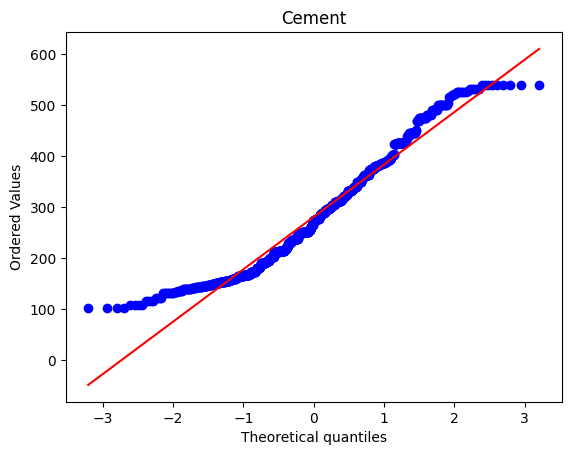

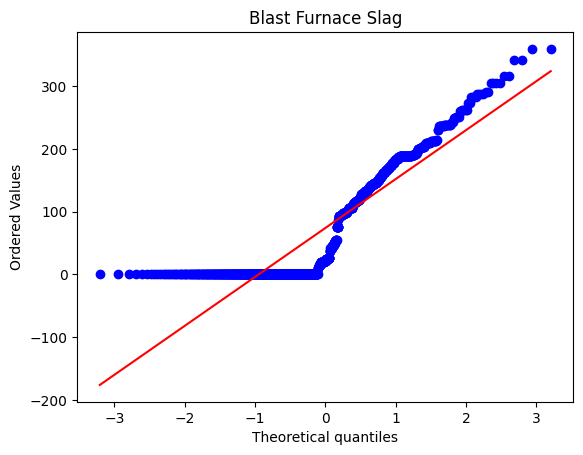

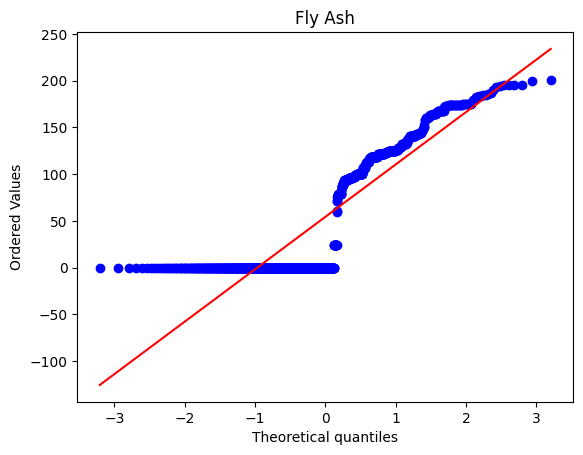

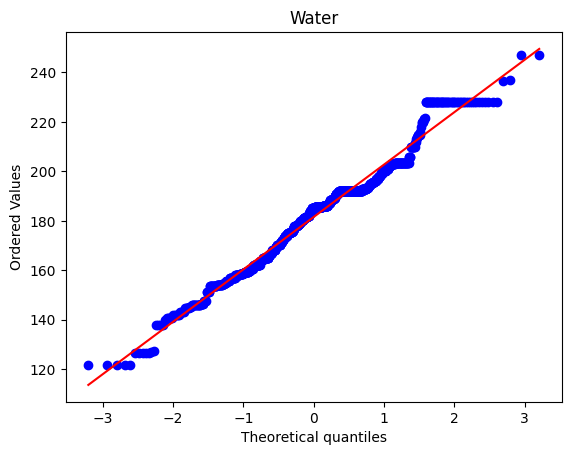

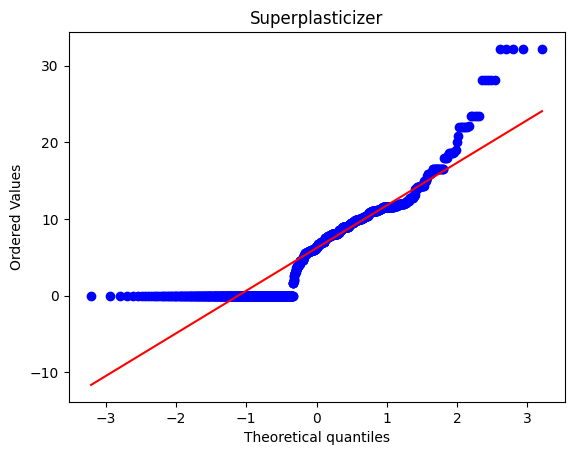

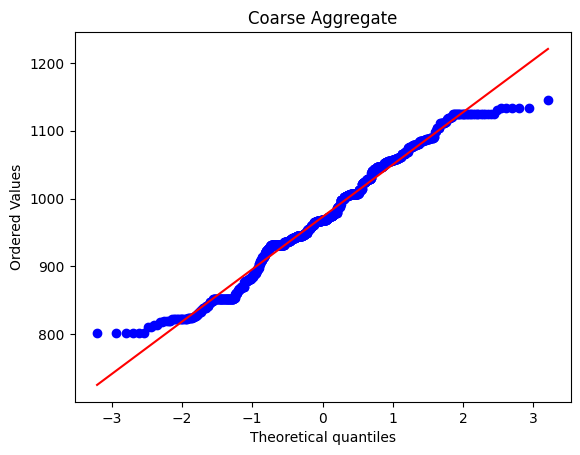

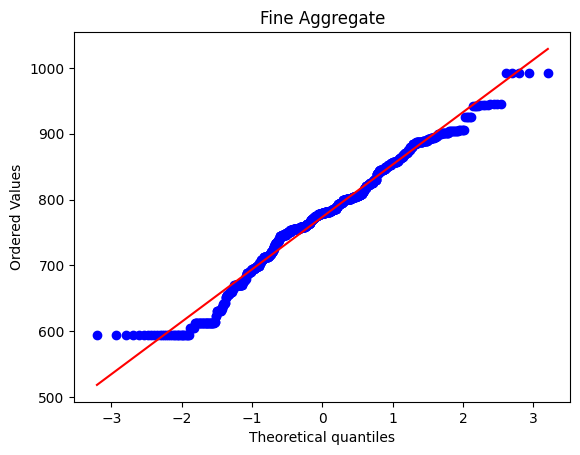

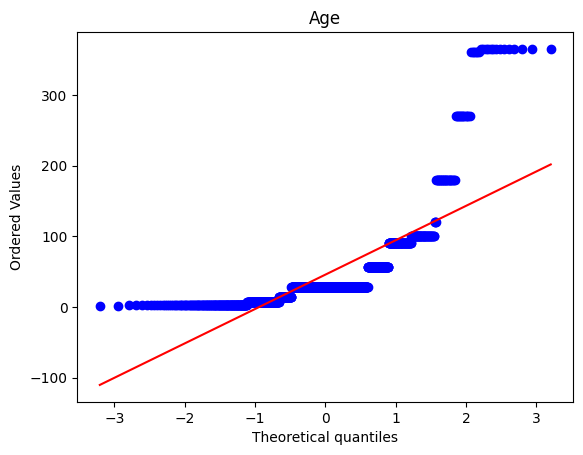

In [128]:
# drawing QQ plot
import scipy.stats as stats
import matplotlib.pyplot as plt

cols=["Cement","Blast Furnace Slag","Fly Ash","Water","Superplasticizer","Coarse Aggregate","Fine Aggregate","Age"]

for col in cols:
    plt.figure()
    stats.probplot(df[col],dist="norm",plot=plt)
    plt.title(col)
    plt.show()


Training model and calculating its score without doing any transformation

In [129]:
# seperate input and output variables
x=df[cols]
y=df[["Strength"]]

In [130]:
x

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360
...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28


In [131]:
y

,Strength
0,79.99
1,61.89
2,40.27
3,41.05
4,44.30
...,...
1025,44.28
1026,31.18
1027,23.70
1028,32.77


In [132]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [133]:
x_train

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
406,165.0,0.0,143.6,163.8,0.0,1005.6,900.9,3
15,380.0,0.0,0.0,228.0,0.0,932.0,670.0,90
468,213.5,0.0,174.2,159.2,11.7,1043.6,771.9,100
255,212.5,0.0,100.4,159.3,8.7,1007.8,903.6,14
342,297.2,0.0,117.5,174.8,9.5,1022.8,753.5,56
...,...,...,...,...,...,...,...,...
786,331.0,0.0,0.0,192.0,0.0,978.0,825.0,28
171,531.3,0.0,0.0,141.8,28.2,852.1,893.7,91
727,331.0,0.0,0.0,192.0,0.0,1025.0,821.0,7
760,350.0,0.0,0.0,203.0,0.0,974.0,775.0,56


In [134]:
x_test

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
772,382.0,0.0,0.0,186.0,0.0,1047.0,739.0,7
344,213.7,0.0,174.7,154.8,10.2,1053.5,776.4,3
557,255.5,170.3,0.0,185.7,0.0,1026.6,724.3,7
574,135.7,203.5,0.0,185.7,0.0,1076.2,759.3,7
107,323.7,282.8,0.0,183.8,10.3,942.7,659.9,7
...,...,...,...,...,...,...,...,...
141,425.0,106.3,0.0,153.5,16.5,852.1,887.1,56
101,388.6,97.1,0.0,157.9,12.1,852.1,925.7,7
963,150.0,236.8,0.0,173.8,11.9,1069.3,674.8,28
922,255.0,99.0,77.0,189.0,6.0,919.0,749.0,28


In [135]:
# training model
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 8)","[[0.12,0.11,0.09,...,0.02,0.03,0.11]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Cement','Blast Furnace Slag','Fly Ash',...,'Coarse Aggregate', 'Fine Aggregate','Age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-30.18]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [136]:
y_predict=model.predict(x_test)

In [137]:
# calculating score
from sklearn.metrics import r2_score
score=r2_score(y_test,y_predict)

In [138]:
score

0.6524027010977222

In [139]:
# cross validation 
from sklearn.model_selection import cross_val_score
cross_val_score(LinearRegression(),x_train,y_train,cv=10,scoring="r2").mean()

np.float64(0.5907440063285909)

In [148]:
#transformation
from sklearn.preprocessing import PowerTransformer
transfomer=PowerTransformer(method="box-cox",standardize=True)
x_train_transformed=transfomer.fit_transform(x_train+0.0001)
x_test_transformed=transfomer.transform(x_test+0.0001)

transfomer.lambdas_
pd.DataFrame({'col':x_train.columns,'lambda':transfomer.lambdas_})

,col,lambda
0,Cement,0.123900
1,Blast Furnace Slag,0.032092
2,Fly Ash,-0.030908
3,Water,0.800333
4,Superplasticizer,0.142844
5,Coarse Aggregate,1.119893
6,Fine Aggregate,1.790879
7,Age,0.052431


In [141]:
#training
model=LinearRegression()
model.fit(x_train_transformed,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 8)","[[ 8.13, 4.3 ,-0.63,...,-0.74,-1.84, 9.89]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[35.65]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[42.71,34.99,31.34,...,25.49,11.68, 9.28]"


In [142]:
#prediction
y_predict=model.predict(x_test_transformed)

In [143]:
# score
score=r2_score(y_test,y_predict)

In [144]:
score

0.843342960837321

In [145]:
#cross validation
cross_val_score(LinearRegression(),x_train_transformed,y_train,cv=10).mean()

np.float64(0.7842172054198295)